# Multi-participant regime-switching SSMs with `RSSSM`

The [first `RSSSM` tutorial](rsssm_regime_switching.ipynb) fit a single participant with two regimes. Real datasets have **many participants**, and the cognitive states of interest often involve **more than two regimes** — for example a *focused* / *neutral* / *distracted* trichotomy, or three distinct speed–accuracy strategies.

This tutorial scales `RSSSM` to a **panel of participants at $K = 3$ regimes**. It exercises the machinery that makes the class worthwhile beyond a hand-built single-subject model:

- a **single batched forward recursion** over all participants (a Python loop over subjects is prohibitively slow);
- the **`ordered`-transform anchor at $K = 3$**, where the naive soft-constraint approach to label-switching breaks down;
- **per-participant regime recovery** with FFBS;
- a choice of **pooling** across participants.

The generative model is the same as before, now with a third regime and shared chain dynamics across participants:

$$s^{(p)}_t \mid s^{(p)}_{t-1} \sim \text{Categorical}\big(P_{s^{(p)}_{t-1},\,\cdot}\big), \qquad (rt^{(p)}_t, \text{resp}^{(p)}_t) \mid s^{(p)}_t = k \sim \text{DDM}(v_k, a, z, t).$$

## Part 1: Setup
---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az

import hssm

%config InlineBackend.figure_format = "retina"
np.random.seed(0)

## Part 2: Simulate a panel
---

Four participants, 200 trials each, switching between **three** drift regimes with well-separated drift rates $v = [-1.0,\ 0.5,\ 1.8]$ — a *conservative* regime favouring the lower boundary, a *neutral* regime, and an *eager* regime favouring the upper boundary. The boundary, start point, and non-decision time are shared; every participant follows the same sticky 3-state chain. (Panels may be **unbalanced** — `RSSSM` end-pads internally and masks the padding — but we keep them equal here for clarity.)

In [2]:
def simulate_participant(n_trials, v_per_regime, a, z, t, P, pi0, seed):
    rng = np.random.default_rng(seed)
    K = len(v_per_regime)
    regimes = np.empty(n_trials, dtype=int)
    regimes[0] = rng.choice(K, p=pi0)
    for i in range(1, n_trials):
        regimes[i] = rng.choice(K, p=P[regimes[i - 1]])
    data = np.empty((n_trials, 2))
    for k in range(K):
        m = regimes == k
        n_k = int(m.sum())
        if n_k:
            data[m] = hssm.simulate_data(
                model="ddm", theta={"v": v_per_regime[k], "a": a, "z": z, "t": t},
                size=n_k, random_state=seed + k, output_df=False,
            )
    return data, regimes


N_PARTICIPANTS, N_TRIALS = 4, 200
V_TRUE = [-1.0, 0.5, 1.8]
A_TRUE, Z_TRUE, T_TRUE = 1.0, 0.5, 0.3
P_TRUE = np.array([[0.90, 0.05, 0.05], [0.05, 0.90, 0.05], [0.05, 0.05, 0.90]])
PI0_TRUE = np.ones(3) / 3

frames, true_regimes = [], {}
for pid in range(N_PARTICIPANTS):
    data, regimes = simulate_participant(
        N_TRIALS, V_TRUE, A_TRUE, Z_TRUE, T_TRUE, P_TRUE, PI0_TRUE, seed=10 + pid
    )
    sub = pd.DataFrame(data, columns=["rt", "response"])
    sub["participant_id"] = pid
    frames.append(sub)
    true_regimes[pid] = regimes
df = pd.concat(frames, ignore_index=True)
df.groupby("participant_id").size().rename("n_trials")

participant_id
0    200
1    200
2    200
3    200
Name: n_trials, dtype: int64

The three regimes are visible directly in the signed RTs of one participant — the conservative regime sits below zero, the eager regime above:

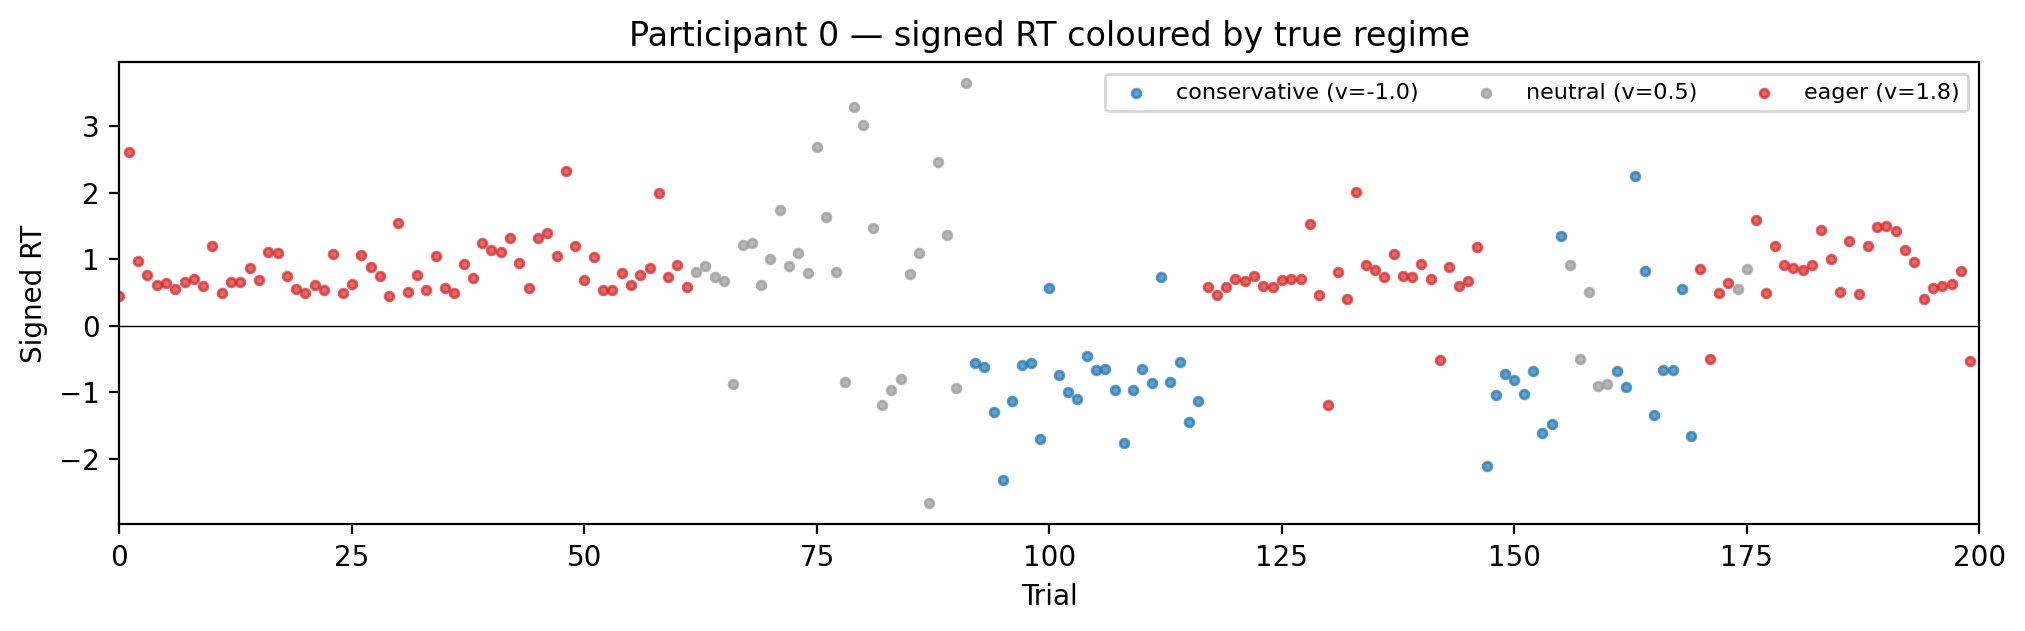

In [3]:
colors = {0: "#1f77b4", 1: "#999999", 2: "#d62728"}
names = {0: "conservative (v=-1.0)", 1: "neutral (v=0.5)", 2: "eager (v=1.8)"}
fig, ax = plt.subplots(figsize=(12, 3))
reg0 = true_regimes[0]
trials = np.arange(N_TRIALS)
sub0 = df[df["participant_id"] == 0]
for k in (0, 1, 2):
    m = reg0 == k
    ax.scatter(trials[m], sub0["rt"].values[m] * sub0["response"].values[m],
               s=10, alpha=0.7, color=colors[k], label=names[k])
ax.axhline(0, color="k", lw=0.5)
ax.set_xlabel("Trial"); ax.set_ylabel("Signed RT"); ax.set_xlim(0, N_TRIALS)
ax.legend(loc="upper right", ncol=3, fontsize=8)
ax.set_title("Participant 0 — signed RT coloured by true regime"); plt.show()

## Part 3: Build the model
---

`participant_col` tells `RSSSM` how the rows group into participants. Under the default **full pooling** the regime parameters are *global* — shared across participants — which is the right choice when participants are believed to occupy the same cognitive regimes. The transition matrix $P$ and initial distribution $\pi_0$ are **always** global. The drift rate switches across the three regimes and anchors the ordering.

> **Pooling.** `RSSSM` also supports `pooling="none"`, where every participant gets *independent* SSM parameters (shapes $(N, K)$ for switching params, $(N,)$ for shared). We illustrate that below. *Partial* (hierarchical) pooling is on the roadmap.

In [4]:
model = hssm.RSSSM(
    data=df,
    model="ddm",
    K=3,
    switching_params=["v"],
    participant_col="participant_id",
    v={"name": "Normal", "mu": 0.0, "sigma": 3.0},
    a={"name": "HalfNormal", "sigma": 2.0},
    z={"name": "Beta", "alpha": 10, "beta": 10},
    t={"name": "HalfNormal", "sigma": 0.5},
)

RSSSM model initialized successfully.


### Why the `ordered` transform matters at $K = 3$

With $K$ regimes the likelihood is invariant to any of the $K!$ relabellings, so the posterior has $K!$ equivalent modes. A *soft* penalty (a `pm.Potential` that punishes mis-ordered draws) happens to work at $K=2$ but **fails at $K \ge 3$** — NUTS trajectories jump across the barrier and chains land in different label permutations, producing inflated R-hat and divergences. `RSSSM` instead parameterises the anchor (`v`) with PyMC's **`ordered` transform**, which makes the permuted modes *unreachable* by construction. Regimes are therefore reported in ascending drift order: regime 0 is the most conservative, regime 2 the most eager.

## Part 4: Fit and check
---

In [5]:
idata = model.sample(draws=1000, tune=1000, chains=2, target_accept=0.9, random_seed=42)

/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/pymc/sampling/jax.py:475: UserWarning: There are not enough devices to run parallel chains: expected 2 but got 1. Chains will be drawn sequentially. If you are running MCMC in CPU, consider using `numpyro.set_host_device_count(2)` at the beginning of your program. You can double-check how many devices are available in your system using `jax.local_device_count()`.
  pmap_numpyro = MCMC(


  0%|          | 0/2000 [00:00<?, ?it/s]

warmup:   0%|          | 1/2000 [00:01<33:53,  1.02s/it, 1 steps of size 1.95e+00. acc. prob=0.00]

warmup:   0%|          | 7/2000 [00:01<04:02,  8.21it/s, 63 steps of size 7.16e-03. acc. prob=0.57]

warmup:   1%|          | 11/2000 [00:01<03:22,  9.83it/s, 63 steps of size 9.30e-03. acc. prob=0.70]

...

sample:  99%|█████████▉| 1985/2000 [00:39<00:00, 54.47it/s, 31 steps of size 2.17e-01. acc. prob=0.94]

sample: 100%|█████████▉| 1991/2000 [00:39<00:00, 51.69it/s, 31 steps of size 2.17e-01. acc. prob=0.94]

sample: 100%|█████████▉| 1998/2000 [00:39<00:00, 55.22it/s, 31 steps of size 2.17e-01. acc. prob=0.94]

sample: 100%|██████████| 2000/2000 [00:39<00:00, 50.19it/s, 15 steps of size 2.17e-01. acc. prob=0.94]

/Users/fmuia/Library/CloudStorage/Dropbox/02-Data-Science/github-projects/HSSM/.venv/lib/python3.13/site-packages/jax/_src/interpreters/mlir.py:1178: UserWarning: Some donated buffers were not usable: ShapedArray(float64[2,1000,3,2]).
See an explanation at https://jax.readthedocs.io/en/latest/faq.html#buffer-donation.
  warnings.warn("Some donated buffers were not usable:"
We recommend running at least 4 chains for robust computation of convergence diagnostics


In [6]:
model.summary()

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
v[0],-1.041,0.109,-1.236,-0.828,0.003,0.002,1145.0,1461.0,1.0
v[1],0.389,0.092,0.232,0.571,0.002,0.002,2438.0,1835.0,1.0
v[2],1.763,0.115,1.553,1.995,0.002,0.003,2135.0,1460.0,1.0
"P[0, 0]",0.891,0.025,0.845,0.938,0.001,0.001,1673.0,1436.0,1.0
"P[0, 1]",0.032,0.019,0.002,0.067,0.001,0.000,1037.0,936.0,1.0
"P[0, 2]",0.077,0.023,0.038,0.121,0.000,0.001,2542.0,1408.0,1.0
"P[1, 0]",0.044,0.019,0.012,0.079,0.000,0.001,1756.0,1305.0,1.0
"P[1, 1]",0.927,0.025,0.879,0.968,0.001,0.001,1697.0,1631.0,1.0
"P[1, 2]",0.029,0.017,0.004,0.062,0.000,0.000,2041.0,1141.0,1.0
"P[2, 0]",0.049,0.016,0.019,0.078,0.000,0.000,1735.0,1694.0,1.0


The three drift rates come back ordered and close to the true $[-1.0, 0.5, 1.8]$, with no label-switching across chains. Side by side with the ground truth:

In [7]:
v_mean = idata.posterior["v"].mean(("chain", "draw")).values
pd.DataFrame({
    "regime": ["0 (conservative)", "1 (neutral)", "2 (eager)"],
    "posterior mean v": np.round(v_mean, 3),
    "true v": V_TRUE,
})

,regime,posterior mean v,true v
0,0 (conservative),-1.041,-1.0
1,1 (neutral),0.389,0.5
2,2 (eager),1.763,1.8


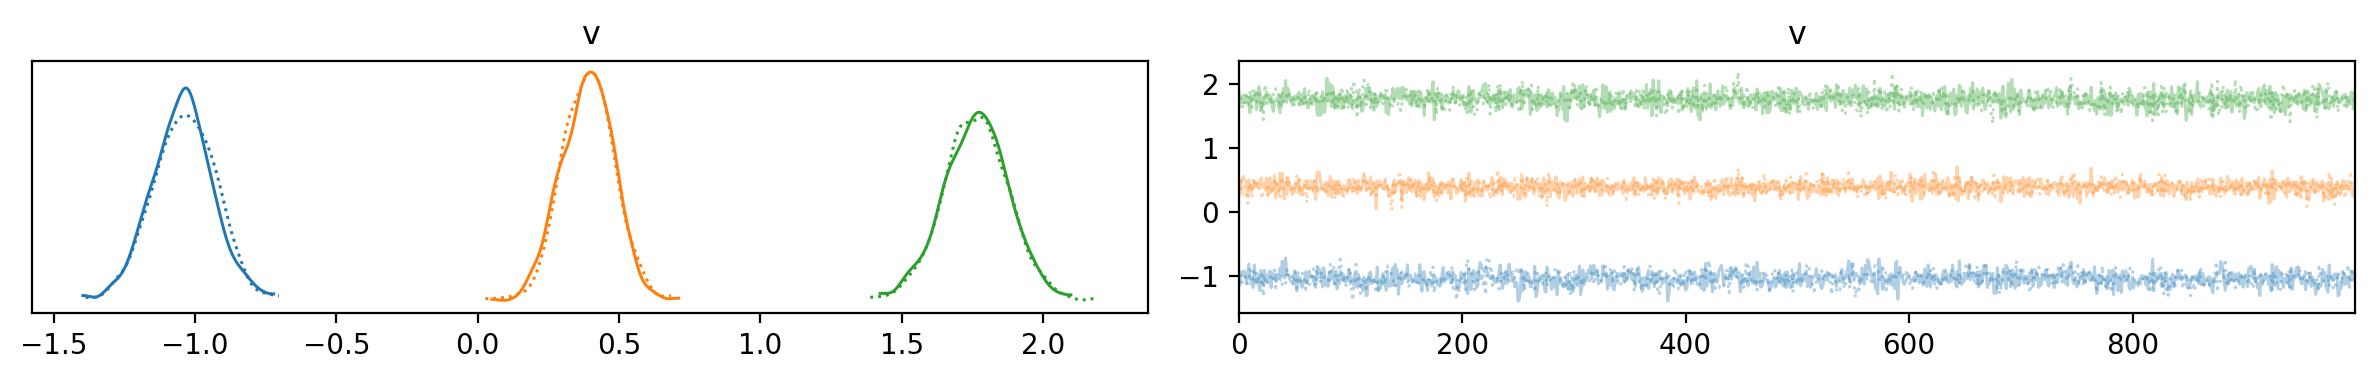

In [8]:
az.plot_trace(idata, var_names=["v"], compact=True); plt.tight_layout()

## Part 5: Per-participant regime recovery
---

`infer_regimes` returns a `posterior_regimes` group with, for every $(\text{participant}, \text{trial})$, the Monte-Carlo posterior probability of each regime. We plot the recovered probabilities against ground truth for all four participants. Because the chain dynamics are global but each participant has their own latent path, FFBS reconstructs a *separate* trajectory per participant from the same posterior.

In [9]:
regimes_idata = model.infer_regimes(idata, n_draws=200, seed=0)

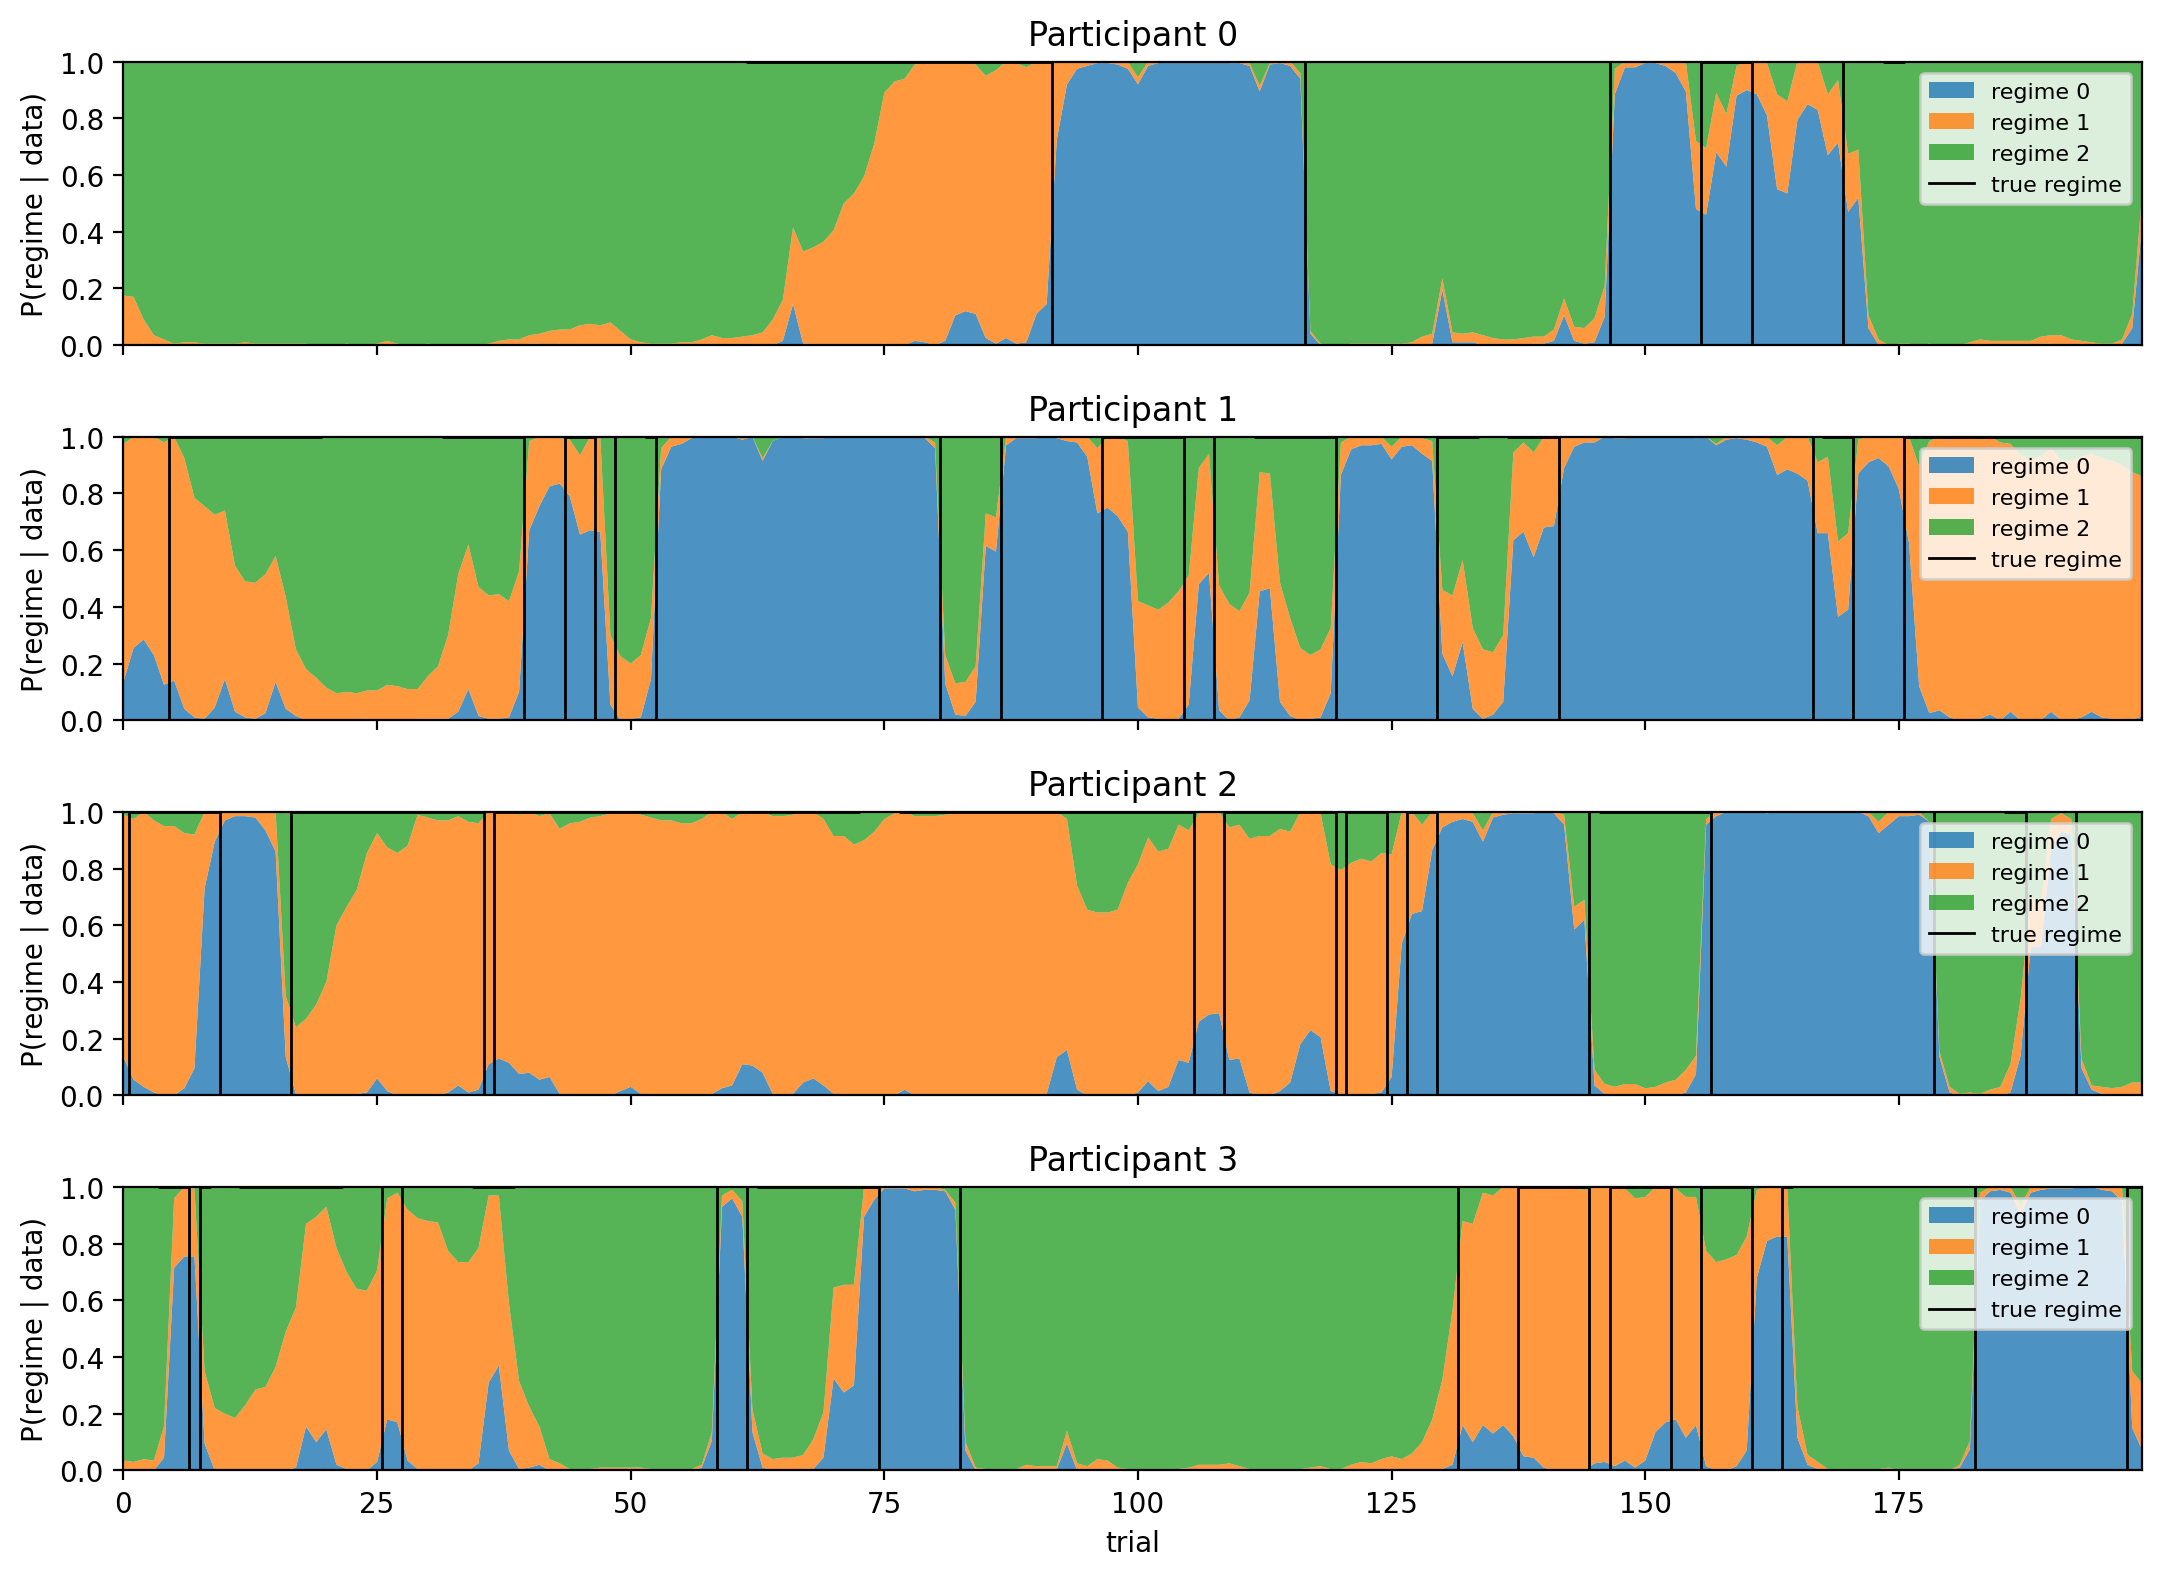

In [10]:
fig, axes = plt.subplots(N_PARTICIPANTS, 1, figsize=(11, 8), sharex=True)
for pid, ax in enumerate(axes):
    model.plot_regime_recovery(
        regimes_idata, participant=pid, true_regimes=true_regimes[pid], ax=ax
    )
    ax.set_title(f"Participant {pid}")
    if pid < N_PARTICIPANTS - 1:
        ax.set_xlabel("")
fig.tight_layout()

In [11]:
# Per-trial recovery accuracy, averaged over participants.
accs = []
for pid in range(N_PARTICIPANTS):
    freq = regimes_idata.posterior_regimes["regime_sample_frequency"].values[pid]
    accs.append((freq.argmax(axis=1) == true_regimes[pid]).mean())
print("Per-participant regime accuracy:", [f"{a:.1%}" for a in accs])
print(f"Mean: {np.mean(accs):.1%}")

Per-participant regime accuracy: ['91.0%', '72.5%', '83.0%', '76.5%']
Mean: 80.8%


## Part 6: No pooling — independent participants
---

When participants should **not** be assumed to share regime parameters, use `pooling="none"`. Each participant then gets their own drift vector (shape $(N, K)$) and their own shared parameters (shape $(N,)$), while $P$ and $\pi_0$ remain global and a single batched scan still runs over the whole panel. Here we only build the model to inspect the parameter shapes (fitting is identical to before):

In [12]:
model_nopool = hssm.RSSSM(
    data=df, model="ddm", K=3, switching_params=["v"],
    participant_col="participant_id", pooling="none",
    v={"name": "Normal", "mu": 0.0, "sigma": 3.0},
)
v_full = model.pymc_model["v"].type.shape          # (K,)        global
v_none = model_nopool.pymc_model["v"].type.shape   # (N, K)      per participant
print(f"full pooling   v shape: {v_full}   (one drift vector shared by all)")
print(f"no   pooling   v shape: {v_none}   (a drift vector per participant)")

RSSSM model initialized successfully.


full pooling   v shape: (3,)   (one drift vector shared by all)
no   pooling   v shape: (4, 3)   (a drift vector per participant)


## Part 7: Model comparison
---

As in the single-participant tutorial, per-trial log-likelihoods are reconstructed post-hoc so `arviz.loo` / `arviz.waic` can score the fit. To choose $K$ in practice, fit several values and compare their `loo` (interpreting with the usual care for dependent HMM observations).

In [13]:
model.compute_log_likelihood(idata)
az.loo(idata)

Computed from 2000 posterior samples and 800 observations log-likelihood matrix.

         Estimate       SE
elpd_loo  -834.43    33.50
p_loo       10.01        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)      800  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

## Part 8: Summary and extensions
---

### What we did

- Fit a **panel of participants** with a **$K = 3$** regime-switching DDM in a single `RSSSM(...)` call, with one batched forward recursion over all participants.
- Recovered three ordered drift regimes with no label-switching — the `ordered`-transform anchor doing the work that a soft constraint cannot at $K \ge 3$.
- Reconstructed a **separate regime trajectory per participant** with `infer_regimes`, and quantified recovery against ground truth.
- Saw how `pooling="full"` vs `"none"` changes the parameter structure while keeping $P$ / $\pi_0$ global.

### Where to go next

- **Unbalanced panels.** Drop the equal-length assumption — `RSSSM` end-pads and masks automatically; the marginal is exact.
- **Per-regime lapses.** Add `"p_outlier"` to `switching_params` to give each regime its own lapse rate.
- **LAN emissions.** Use `loglik_kind="approx_differentiable"` to fit SSMs with no analytical likelihood (e.g. `model="angle"`); FFBS and `loo` work identically.
- **Hierarchical pooling** of regime parameters across participants is the natural next step (partial pooling), planned as a future extension.